In [1]:
import torch
import numpy as np
import pandas as pd
from itertools import product
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score
from data import get_spectrograms
from models import SpeechExtractorModule

## Config

In [39]:
DEVICE            = torch.device("mps")
CKPT_PATH         = "../best.ckpt"
DATA_DIR          = "../data"
TARGET_CLASS      = "yes"
ADVERSARIAL_CLASS = "no"
EVAL_SUBSET       = "validation"
N_EVAL            = 200

# Put a list to sweep, a single value to fix
SWEEP = {
    "n_train":         [10, 20, 30, 50, 100, 200],
    "n_components":    [1, 2],
    "covariance_type": ["full", "diag"],
    "percentile":      5.0,
}

## Load extractor

In [40]:
extractor = SpeechExtractorModule.load_from_checkpoint(CKPT_PATH)
extractor = extractor.to(DEVICE)
extractor.eval()

SpeechExtractorModule(
  (model): SpeechFeatureExtractor(
    (backbone): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
      (12): Flatten(start_dim=1, end_dim=-1)
    )
    (embedding_head): Sequential(
      (0): Linear(in_features=128, out_features

## GMM experiment

In [41]:
def run_gmm_experiment(
    extractor,
    data_dir: str,
    target_class: str,
    adversarial_class: str,
    n_train: int,
    n_eval: int          = 50,
    n_components: int    = 4,
    covariance_type: str = "diag",
    percentile: float    = 5.0,
    eval_subset: str     = "validation",
    device: torch.device = torch.device("mps"),
) -> dict:

    if n_train < n_components:
        print(f"n_tran ({n_train}) < n_components ({n_components}), quitting")
        return None

    # --- Train ---
    specs = get_spectrograms(data_dir, target_class=target_class, n=n_train, subset="training").to(device)
    with torch.no_grad():
        embeddings = extractor(specs, return_embedding=True).cpu().numpy()

    gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, random_state=42)
    gmm.fit(embeddings)
    train_scores = gmm.score_samples(embeddings)
    threshold = np.percentile(train_scores, percentile)

    # --- Eval ---
    correct_specs     = get_spectrograms(data_dir, target_class=target_class,     n=n_eval, subset=eval_subset).to(device)
    adversarial_specs = get_spectrograms(data_dir, target_class=adversarial_class, n=n_eval, subset=eval_subset).to(device)

    with torch.no_grad():
        correct_embeddings     = extractor(correct_specs,     return_embedding=True).cpu().numpy()
        adversarial_embeddings = extractor(adversarial_specs, return_embedding=True).cpu().numpy()

    correct_scores     = gmm.score_samples(correct_embeddings)
    adversarial_scores = gmm.score_samples(adversarial_embeddings)

    correct_accepted     = (correct_scores >= threshold).sum()
    adversarial_rejected = (adversarial_scores < threshold).sum()

    tpr = correct_accepted / n_eval
    tnr = adversarial_rejected / n_eval

    all_scores = np.concatenate([correct_scores, adversarial_scores])
    all_labels = np.array([1] * n_eval + [0] * n_eval)

    return {
        "n_train":      n_train,
        "n_components": n_components,
        "covariance_type": covariance_type,
        "percentile":   percentile,
        "tpr":          tpr,
        "tnr":          tnr,
        "accuracy":     (correct_accepted + adversarial_rejected) / (2 * n_eval),
        "auroc":        roc_auc_score(all_labels, all_scores),
    }

## Sweep

In [42]:
def expand_grid(sweep: dict) -> list[dict]:
    """Expand a sweep dict into a list of configs, taking the product of all list values."""
    keys   = list(sweep.keys())
    values = [v if isinstance(v, list) else [v] for v in sweep.values()]
    return [dict(zip(keys, combo)) for combo in product(*values)]

In [43]:
rows = []
configs = expand_grid(SWEEP)
print(f"Running {len(configs)} experiments...")

for cfg in configs:
    result = run_gmm_experiment(
        extractor=extractor,
        data_dir=DATA_DIR,
        target_class=TARGET_CLASS,
        adversarial_class=ADVERSARIAL_CLASS,
        n_eval=N_EVAL,
        eval_subset=EVAL_SUBSET,
        device=DEVICE,
        **cfg,
    )
    if result is not None:
        rows.append(result)
        swept_str = "  ".join(f"{k}={v}" for k, v in cfg.items())
        print(f"{swept_str}  →  TPR={result['tpr']:.2f}  TNR={result['tnr']:.2f}  Acc={result['accuracy']:.2f}  AUROC={result['auroc']:.2f}")

df = pd.DataFrame(rows)
df

Running 24 experiments...
n_train=10  n_components=1  covariance_type=full  percentile=5.0  →  TPR=0.00  TNR=1.00  Acc=0.50  AUROC=0.85
n_train=10  n_components=1  covariance_type=diag  percentile=5.0  →  TPR=0.76  TNR=1.00  Acc=0.88  AUROC=0.97
n_train=10  n_components=2  covariance_type=full  percentile=5.0  →  TPR=0.00  TNR=1.00  Acc=0.50  AUROC=0.97
n_train=10  n_components=2  covariance_type=diag  percentile=5.0  →  TPR=0.46  TNR=1.00  Acc=0.73  AUROC=0.98
n_train=20  n_components=1  covariance_type=full  percentile=5.0  →  TPR=0.00  TNR=1.00  Acc=0.50  AUROC=0.73
n_train=20  n_components=1  covariance_type=diag  percentile=5.0  →  TPR=0.68  TNR=1.00  Acc=0.84  AUROC=0.96
n_train=20  n_components=2  covariance_type=full  percentile=5.0  →  TPR=0.00  TNR=1.00  Acc=0.50  AUROC=0.74
n_train=20  n_components=2  covariance_type=diag  percentile=5.0  →  TPR=0.49  TNR=1.00  Acc=0.74  AUROC=0.96
n_train=30  n_components=1  covariance_type=full  percentile=5.0  →  TPR=0.03  TNR=1.00  Acc=0

,n_train,n_components,covariance_type,percentile,tpr,tnr,accuracy,auroc
0,10,1,full,5.0,0.000,1.000,0.5000,0.849850
1,10,1,diag,5.0,0.760,1.000,0.8800,0.972800
2,10,2,full,5.0,0.000,1.000,0.5000,0.965575
3,10,2,diag,5.0,0.455,1.000,0.7275,0.976850
4,20,1,full,5.0,0.000,1.000,0.5000,0.728275
5,20,1,diag,5.0,0.680,1.000,0.8400,0.957775
6,20,2,full,5.0,0.000,1.000,0.5000,0.737275
7,20,2,diag,5.0,0.490,1.000,0.7450,0.959400
8,30,1,full,5.0,0.030,1.000,0.5150,0.842325
9,30,1,diag,5.0,0.660,1.000,0.8300,0.965050


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metric_vs(df, x, metric="auroc", hue=None, title=None):
    """Line plot of a metric vs a swept parameter, optionally grouped by another."""
    fig, ax = plt.subplots(figsize=(7, 4))
    if hue:
        for val, group in df.groupby(hue):
            ax.plot(group[x], group[metric], marker="o", label=f"{hue}={val}")
        ax.legend(title=hue)
    else:
        ax.plot(df[x], df[metric], marker="o")
    ax.set_xlabel(x)
    ax.set_ylabel(metric)
    ax.set_title(title or f"{metric} vs {x}")
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def plot_heatmap(df, row, col, metric="auroc", title=None):
    """Heatmap of a metric over two swept parameters."""
    pivot = df.pivot(index=row, columns=col, values=metric)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", ax=ax)
    ax.set_title(title or f"{metric} — {row} vs {col}")
    plt.tight_layout()
    plt.show()


def plot_all_metrics(df, x, hue=None):
    """Line plots for all 4 metrics side by side."""
    metrics = ["tpr", "tnr", "accuracy", "auroc"]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, metric in zip(axes, metrics):
        if hue:
            for val, group in df.groupby(hue):
                ax.plot(group[x], group[metric], marker="o", label=f"{hue}={val}")
            ax.legend(title=hue, fontsize=7)
        else:
            ax.plot(df[x], df[metric], marker="o")
        ax.set_xlabel(x)
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.grid(True)
    plt.tight_layout()
    plt.show()

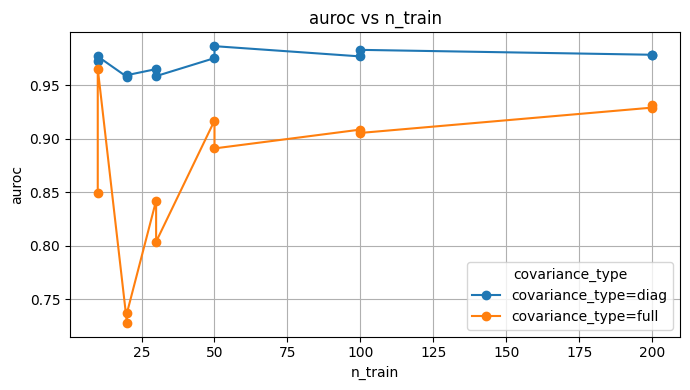

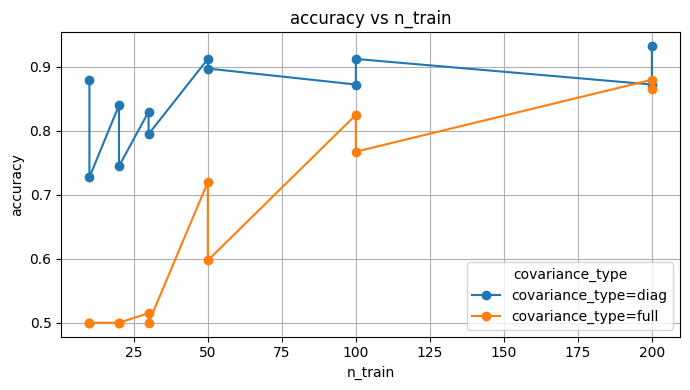

In [45]:
# %%
plot_metric_vs(df, x="n_train", metric="auroc", hue="covariance_type")
plot_metric_vs(df, x="n_train", metric="accuracy", hue="covariance_type")

# plot_heatmap(df, row="n_train", col="n_components", metric="auroc")

# plot_all_metrics(df, x="n_train", hue="n_components")